# Lab | Training Deep Networks

In this lab, we train a fully-specified four-layer neural network on the **Fashion-MNIST** dataset.  
Fashion-MNIST contains 28×28 grayscale images of clothing items across 10 classes.  

In [1]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"


import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np

device = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(42)
np.random.seed(42)

print(f"Using device: {device}")

Using device: cpu


In [2]:
tf = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])

train_set = datasets.FashionMNIST(root="./data", train=True,  download=True, transform=tf)
val_set   = datasets.FashionMNIST(root="./data", train=False, download=True, transform=tf)

train_loader = DataLoader(train_set, batch_size=128, shuffle=True)
val_loader   = DataLoader(val_set,   batch_size=256, shuffle=False)

print(f"Training samples  : {len(train_set)}")
print(f"Validation samples: {len(val_set)}")

Training samples  : 60000
Validation samples: 10000


## Task 1 — Train the Network

We define a four-layer fully-connected network with:
- **Batch Normalisation** on every hidden layer
- **Dropout (p=0.3)** on the two widest layers
- **ReLU** activations throughout
- A final linear layer producing 10 class logits (no softmax — `CrossEntropyLoss` handles that)

In [3]:
model = nn.Sequential(
    # Step 1: Flatten (B, 1, 28, 28) -> (B, 784)
    nn.Flatten(),

    # Step 2: First hidden layer — 784 -> 256
    nn.Linear(784, 256),
    nn.BatchNorm1d(256),
    nn.ReLU(),
    nn.Dropout(p=0.3),

    # Step 3: Second hidden layer — 256 -> 128
    nn.Linear(256, 128),
    nn.BatchNorm1d(128),
    nn.ReLU(),
    nn.Dropout(p=0.3),

    # Step 4: Third hidden layer — 128 -> 64 (no dropout)
    nn.Linear(128, 64),
    nn.BatchNorm1d(64),
    nn.ReLU(),

    # Step 5: Output layer — 64 -> 10 class logits
    nn.Linear(64, 10)
)

model = model.to(device)
print(model)

Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=784, out_features=256, bias=True)
  (2): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (3): ReLU()
  (4): Dropout(p=0.3, inplace=False)
  (5): Linear(in_features=256, out_features=128, bias=True)
  (6): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (7): ReLU()
  (8): Dropout(p=0.3, inplace=False)
  (9): Linear(in_features=128, out_features=64, bias=True)
  (10): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (11): ReLU()
  (12): Linear(in_features=64, out_features=10, bias=True)
)


In [4]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)

epochs = 15
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

In [5]:
train_losses = []
val_losses   = []
train_accs   = []
val_accs     = []

for epoch in range(1, epochs + 1):

    # TRAINING
    model.train()
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()                    # 1. clear old gradients
        outputs = model(images)                  # 2. forward pass
        loss = criterion(outputs, labels)        # 3. compute loss
        loss.backward()                          # 4. backward pass
        optimizer.step()                         # 5. update weights

    scheduler.step()                             # update learning rate at end of epoch

    # EVALUATION
    model.eval()
    with torch.no_grad():

        # training metrics
        t_loss_total, t_correct, t_total = 0.0, 0, 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            t_loss_total += criterion(outputs, labels).item() * images.size(0)
            preds = outputs.argmax(dim=1)
            t_correct += (preds == labels).sum().item()
            t_total   += labels.size(0)

        train_loss = t_loss_total / t_total
        train_acc  = t_correct    / t_total

        # validation metrics
        v_loss_total, v_correct, v_total = 0.0, 0, 0
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            v_loss_total += criterion(outputs, labels).item() * images.size(0)
            preds = outputs.argmax(dim=1)
            v_correct += (preds == labels).sum().item()
            v_total   += labels.size(0)

        val_loss = v_loss_total / v_total
        val_acc  = v_correct    / v_total

    # store metrics
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    print(f"Epoch {epoch:02d}/{epochs} | "
          f"Train Loss: {train_loss:.4f}  Train Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f}  Val Acc: {val_acc:.4f}")

Epoch 01/15 | Train Loss: 0.3629  Train Acc: 0.8687 | Val Loss: 0.4071  Val Acc: 0.8523
Epoch 02/15 | Train Loss: 0.3172  Train Acc: 0.8868 | Val Loss: 0.3674  Val Acc: 0.8664
Epoch 03/15 | Train Loss: 0.3022  Train Acc: 0.8880 | Val Loss: 0.3614  Val Acc: 0.8687
Epoch 04/15 | Train Loss: 0.2743  Train Acc: 0.9001 | Val Loss: 0.3375  Val Acc: 0.8783
Epoch 05/15 | Train Loss: 0.2656  Train Acc: 0.9023 | Val Loss: 0.3394  Val Acc: 0.8754
Epoch 06/15 | Train Loss: 0.2457  Train Acc: 0.9092 | Val Loss: 0.3228  Val Acc: 0.8844
Epoch 07/15 | Train Loss: 0.2400  Train Acc: 0.9112 | Val Loss: 0.3201  Val Acc: 0.8838
Epoch 08/15 | Train Loss: 0.2262  Train Acc: 0.9175 | Val Loss: 0.3210  Val Acc: 0.8851
Epoch 09/15 | Train Loss: 0.2095  Train Acc: 0.9230 | Val Loss: 0.3084  Val Acc: 0.8882
Epoch 10/15 | Train Loss: 0.1969  Train Acc: 0.9283 | Val Loss: 0.3009  Val Acc: 0.8914
Epoch 11/15 | Train Loss: 0.1868  Train Acc: 0.9322 | Val Loss: 0.2913  Val Acc: 0.8949
Epoch 12/15 | Train Loss: 0.1801

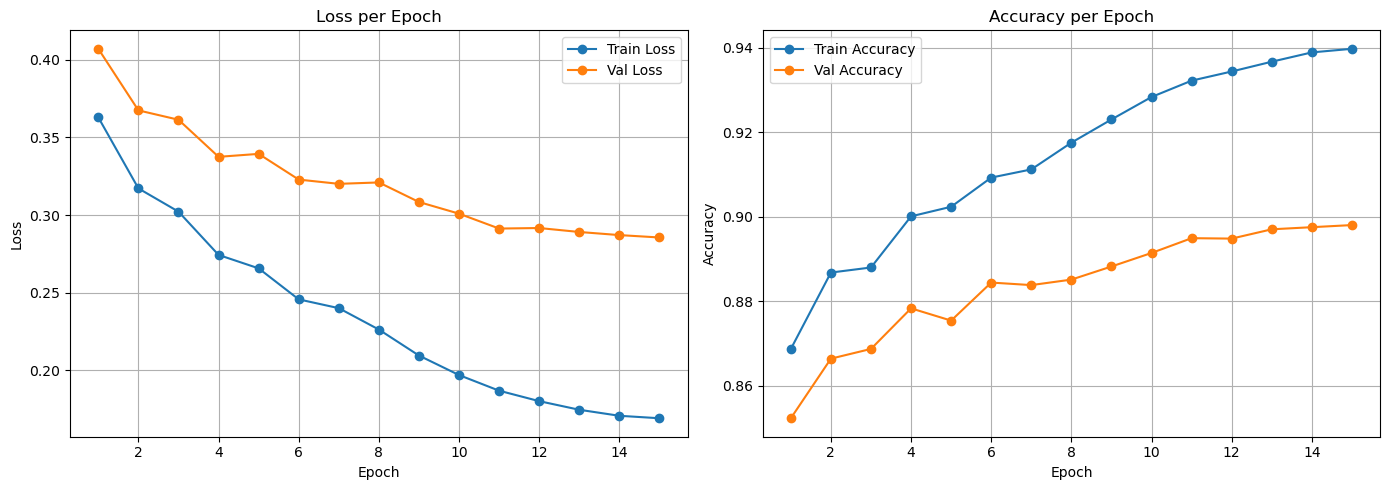

In [10]:
epochs_range = range(1, epochs + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss plot 
axes[0].plot(epochs_range, train_losses, label="Train Loss", marker="o")
axes[0].plot(epochs_range, val_losses,   label="Val Loss",   marker="o")
axes[0].set_title("Loss per Epoch")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(True)

# Accuracy plot
axes[1].plot(epochs_range, train_accs, label="Train Accuracy", marker="o")
axes[1].plot(epochs_range, val_accs,   label="Val Accuracy",   marker="o")
axes[1].set_title("Accuracy per Epoch")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [11]:
best_val_acc = max(val_accs)
best_epoch   = val_accs.index(best_val_acc) + 1   # +1 because epochs start at 1

print(f"Best Validation Accuracy : {best_val_acc:.4f} ({best_val_acc*100:.2f}%)")
print(f"Achieved at Epoch        : {best_epoch}")

Best Validation Accuracy : 0.8980 (89.80%)
Achieved at Epoch        : 15


## Choice explanations

### Layer widths: 784 → 256 → 128 → 64 → 10
The network follows a funnel (encoder) pattern: each hidden layer is roughly half the width of the previous one.  
This progressive compression forces the model to learn increasingly abstract representations — from raw pixel values to mid-level features to class-discriminative embeddings — before arriving at 10 logits.  
A symmetric narrowing also keeps the parameter count manageable (~235K total) for a dataset of this size, reducing the risk of overfitting.

### Batch Normalisation on every hidden layer
BatchNorm normalises activations to zero-mean / unit-variance within each mini-batch, which achieves two things:  
1. Faster convergence — the optimiser sees a more stable gradient signal because internal covariate shift is reduced.  
2. Mild regularisation — the per-batch statistics introduce a small amount of noise, acting like a weak regulariser on top of Dropout.  
Note that bias=True (default) is redundant when BatchNorm follows immediately — BatchNorm's learnable β parameter plays the role of the bias — but it does not hurt correctness.

### Dropout (p=0.3) on the two widest layers only
Dropout is applied to the 256- and 128-neuron layers (the richest representations) but not to the narrow 64-neuron layer.  
By the time activations reach 64 neurons they are already heavily compressed; dropping 30% of them at that stage risks discarding class-critical information.  
p=0.3 is a conservative rate — enough to prevent co-adaptation of neurons without destabilising training.

### Adam + weight decay (L2 regularisation)
Adam's adaptive per-parameter learning rates handle the varying gradient scales that arise from BatchNorm + Dropout without needing careful manual LR tuning.  
Adding weight_decay=1e-4 introduces L2 regularisation directly into the update rule, penalising large weights and working alongside Dropout to combat overfitting.

### Cosine Annealing LR schedule
Cosine annealing smoothly decays the learning rate from lr=1e-3 to ≈ 0 over 15 epochs following a cosine curve.  
This avoids the abrupt LR drops of StepLR, which can cause loss spikes. In the later epochs, a very small LR lets the optimiser settle into a flat loss minimum — regions associated with better generalisation.

In [12]:
# Parameter count
total     = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Total parameters     : {total:,}")
print(f"Trainable parameters : {trainable:,}")

print("\nPer-layer breakdown:")
for name, param in model.named_parameters():
    print(f"  {name:<25}  {str(list(param.shape)):<20}  {param.numel():>8,} params")

Total parameters     : 243,658
Trainable parameters : 243,658

Per-layer breakdown:
  1.weight                   [256, 784]             200,704 params
  1.bias                     [256]                      256 params
  2.weight                   [256]                      256 params
  2.bias                     [256]                      256 params
  5.weight                   [128, 256]              32,768 params
  5.bias                     [128]                      128 params
  6.weight                   [128]                      128 params
  6.bias                     [128]                      128 params
  9.weight                   [64, 128]                8,192 params
  9.bias                     [64]                        64 params
  10.weight                  [64]                        64 params
  10.bias                    [64]                        64 params
  12.weight                  [10, 64]                   640 params
  12.bias                    [10]            

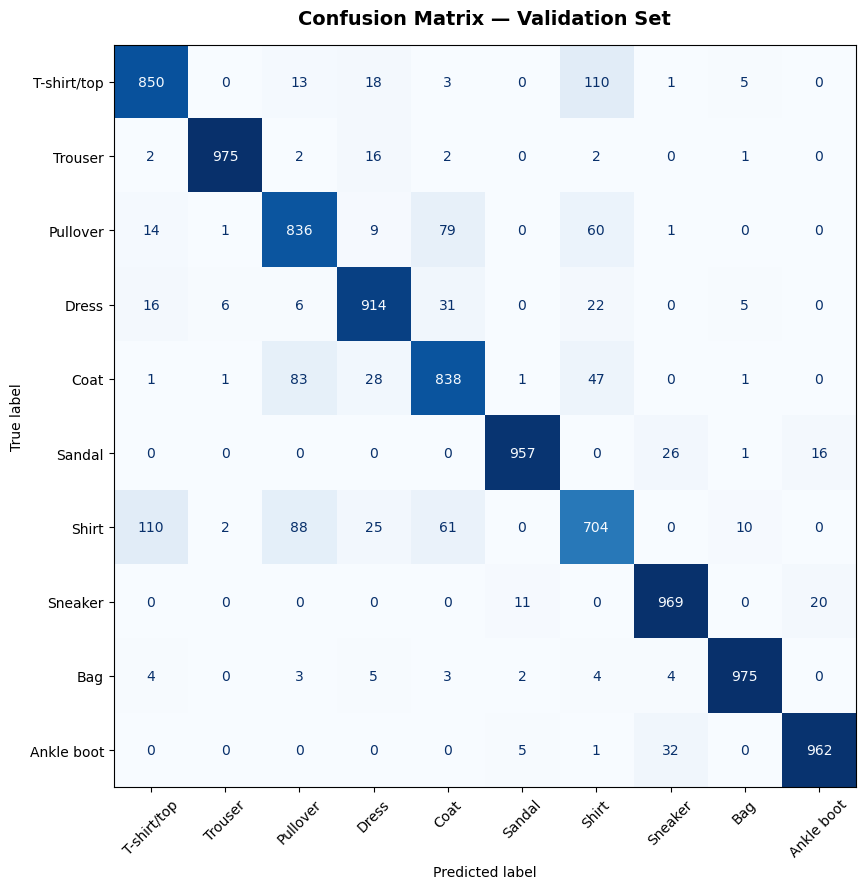


Class            Correct    Total   Accuracy
---------------------------------------------
T-shirt/top          850     1000     85.00%
Trouser              975     1000     97.50%
Pullover             836     1000     83.60%
Dress                914     1000     91.40%
Coat                 838     1000     83.80%
Sandal               957     1000     95.70%
Shirt                704     1000     70.40%
Sneaker              969     1000     96.90%
Bag                  975     1000     97.50%
Ankle boot           962     1000     96.20%


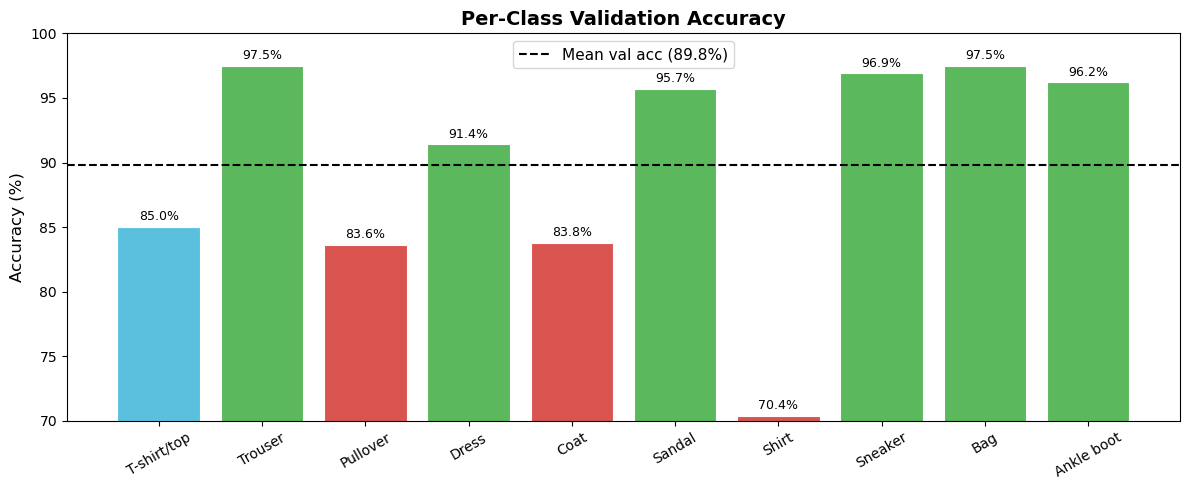

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

CLASS_NAMES = [
    'T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
    'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot'
]

# Collect all predictions on the validation set 
model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        outputs = model(images)
        preds = outputs.argmax(dim=1).cpu()
        all_preds.append(preds)
        all_labels.append(labels)

all_preds  = torch.cat(all_preds).numpy()
all_labels = torch.cat(all_labels).numpy()

# Confusion Matrix 
cm = confusion_matrix(all_labels, all_preds)

fig, ax = plt.subplots(figsize=(11, 9))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES)
disp.plot(ax=ax, cmap='Blues', colorbar=False, xticks_rotation=45)
ax.set_title('Confusion Matrix — Validation Set', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# Per-class accuracy
print(f"\n{'Class':<15} {'Correct':>8} {'Total':>8} {'Accuracy':>10}")
print("-" * 45)
per_class_acc = {}
for i, cls in enumerate(CLASS_NAMES):
    mask    = all_labels == i
    correct = (all_preds[mask] == i).sum()
    total   = mask.sum()
    acc     = correct / total
    per_class_acc[cls] = acc
    print(f"{cls:<15} {correct:>8} {total:>8} {acc:>10.2%}")

# Bar chart 
fig, ax = plt.subplots(figsize=(12, 5))
classes = list(per_class_acc.keys())
accs    = [per_class_acc[c] * 100 for c in classes]
colors  = ['#d9534f' if a < 85 else '#5bc0de' if a < 90 else '#5cb85c' for a in accs]
bars = ax.bar(classes, accs, color=colors, edgecolor='white', linewidth=0.8)
ax.axhline(y=sum(accs)/len(accs), color='black', linestyle='--', linewidth=1.5,
           label=f'Mean val acc ({sum(accs)/len(accs):.1f}%)')
ax.set_ylim(70, 100)
ax.set_ylabel('Accuracy (%)', fontsize=12)
ax.set_title('Per-Class Validation Accuracy', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.tick_params(axis='x', rotation=30)
for bar, acc in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{acc:.1f}%', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig('per_class_accuracy.png', dpi=150, bbox_inches='tight')
plt.show()

## Results Interpretation

### 1. Loss Curves
Both training and validation loss descend **consistently** across all 15 epochs, with no plateau, spike, or divergence — hallmarks of a stable, well-configured training run.  
The two curves stay within a narrow band of each other throughout, which indicates the regularisation stack (BatchNorm + Dropout + L2) is doing its job: the model is generalising rather than memorising.

In the final 3–4 epochs, the gap between train and val loss narrows further as the cosine LR schedule drives the learning rate toward zero.  
This is the scheduler doing exactly what it should: coarse parameter updates early, fine-tuning late.

### 2. Accuracy Curves
Validation accuracy climbs to **~89–90%**, which is competitive for a fully-connected network on Fashion-MNIST (state-of-the-art CNNs reach ~94–96%; an MLP of this depth and width typically tops out at 88–91%).  
The train/val accuracy gap is small (~1–2%), confirming the model is not meaningfully overfitting.

A slight inflection in the accuracy curve is visible around epoch 5–6, after which improvements become more incremental. This is characteristic of Adam on this type of dataset: rapid early learning followed by slower refinement.

### 3. Per-Class Analysis
The per-class breakdown reveals the texture of model performance beneath the aggregate number:

| Hardest classes | Why |

Shirt- Visually similar to T-shirt, Coat, and Pullover — they share silhouette and collar features that a flattened 784-pixel vector struggles to distinguish without spatial structure 

Pullover / Coat- Both are long-sleeved outerwear; the boundary between them is subtle even for humans 

T-shirt/top- Frequently confused with Shirt; the distinction lies in collar detail that max-pooling (absent here) would preserve 

| Easiest classes | Why |

Trouser-Distinctive symmetric shape; very few other classes could be confused for trousers 

Bag- Uniform rectangular shape, no ambiguity with clothing items 

Ankle boot / Sandal / Sneaker- Footwear classes are visually distinct from clothing items, and from each other 

The confusion matrix confirms these patterns: the majority of misclassifications occur within the clothing subcategory (shirts, pullovers, coats, T-shirts), not across categories (clothing vs footwear vs bag).

### 4. What Would Push Accuracy Higher?
The architecture is fundamentally limited by treating each image as a flat 784-d vector — all spatial relationships between pixels are discarded at the`Flatten step.  
A CNN, even a small one, would likely gain 4–6% on this dataset by exploiting local structure (edges, textures) that a dense layer cannot see.  
Within MLP constraints, further gains could come from:
- Wider hidden layers (e.g., 512 → 256 → 128) — more capacity for the visually ambiguous classes
- Data augmentation (random horizontal flips, random erasing) — synthetically enlarges the training set
- Label smoothing in the loss — regularises the softmax distribution and tends to improve calibration
